### Robust ECG alignment: paper extraction vs digital ground truth

This notebook compares `outputs/ecg_may/ecg_signals_mv.npz` against `PMI(100).npz`.

The alignment is intentionally more forgiving than a single global cross-correlation:

1. Baseline-correct and robustly normalize both signals.
2. Build an ECG-pattern feature from amplitude, slope, and smoothed energy.
3. Search for the best local horizontal alignment over lag and a small time-scale range, so the paper trace may be shorter/longer or contain extra/missing parts.
4. Fit vertical gain and offset only on the overlapping aligned samples.

The right-side overlay plots the paper signal after horizontal alignment plus vertical gain/offset correction.


In [2]:
\
import numpy as np
import matplotlib.pyplot as plt

from scipy.ndimage import median_filter, uniform_filter1d
from scipy.signal import find_peaks, resample_poly

extracted_path = r"uploads/digitized/ff8d0452-4de4-46e5-889f-818b4e0bc830/ecg_signals_mv.npz"
truth_path = r"PMI(100).npz"

extr_data = np.load(extracted_path)
truth_data = np.load(truth_path)

fs_truth = float(truth_data["sampling_rate"]) if "sampling_rate" in truth_data.files else 500.0
fs_extr = float(extr_data["sampling_rate"]) if "sampling_rate" in extr_data.files else fs_truth

print("Extracted keys:", extr_data.files)
print("Truth keys:", truth_data.files)
print(f"Sampling rates: truth={fs_truth:g} Hz, extracted={fs_extr:g} Hz")


Extracted keys: ['I', 'aVR', 'V1', 'V4', 'II', 'aVL', 'V2', 'V5', 'III', 'aVF', 'V3', 'V6', 'RHYTHM', 'sampling_rate']
Truth keys: ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'RHYTHM', 'sampling_rate']
Sampling rates: truth=500 Hz, extracted=500 Hz


In [3]:
\
def fill_nan(x):
    x = np.asarray(x, dtype=float)
    if np.isfinite(x).all():
        return x
    good = np.flatnonzero(np.isfinite(x))
    if len(good) == 0:
        return np.zeros_like(x, dtype=float)
    filled = x.copy()
    bad = np.flatnonzero(~np.isfinite(x))
    filled[bad] = np.interp(bad, good, x[good])
    return filled


def robust_z(x, eps=1e-9):
    x = np.asarray(x, dtype=float)
    med = np.median(x)
    mad = np.median(np.abs(x - med))
    scale = 1.4826 * mad
    if scale < eps:
        scale = np.std(x) + eps
    return (x - med) / scale


def baseline_correct(x, fs):
    x = fill_nan(x)
    # A 200 ms median removes slow baseline wander without erasing QRS complexes.
    win = max(3, int(round(0.20 * fs)))
    if win % 2 == 0:
        win += 1
    baseline = median_filter(x, size=win, mode="nearest")
    return x - baseline


def alignment_feature(x, fs):
    centered = baseline_correct(x, fs)
    z = robust_z(centered)
    z = np.clip(z, -6, 6)
    dz = np.diff(z, prepend=z[0])

    energy = np.abs(z) + 0.8 * np.abs(dz)
    smooth_win = max(3, int(round(0.045 * fs)))
    energy = uniform_filter1d(energy, size=smooth_win, mode="nearest")
    return robust_z(energy)


def resample_if_needed(x, src_fs, dst_fs):
    if abs(src_fs - dst_fs) < 1e-6:
        return np.asarray(x, dtype=float)
    # Keep integer factors bounded and deterministic.
    from fractions import Fraction

    ratio = Fraction(dst_fs / src_fs).limit_denominator(1000)
    return resample_poly(np.asarray(x, dtype=float), ratio.numerator, ratio.denominator)


def detect_anchor_peaks(feature, fs):
    distance = max(1, int(round(0.25 * fs)))
    height = np.percentile(feature, 70)
    prominence = max(0.25, np.percentile(feature, 85) - np.percentile(feature, 50))
    peaks, props = find_peaks(feature, height=height, distance=distance, prominence=prominence)
    return peaks


def normalized_overlap_score(truth_feat, paper_feat, offset, scale):
    # Map paper sample index p to truth index t = offset + scale*p and score overlap.
    truth_idx = np.arange(len(truth_feat), dtype=float)
    paper_pos = (truth_idx - offset) / scale
    valid = (paper_pos >= 0) & (paper_pos <= len(paper_feat) - 1)
    if valid.sum() < max(80, 0.15 * min(len(truth_feat), len(paper_feat))):
        return -np.inf, valid, None

    p_interp = np.interp(paper_pos[valid], np.arange(len(paper_feat)), paper_feat)
    g = truth_feat[valid] - np.mean(truth_feat[valid])
    p = p_interp - np.mean(p_interp)
    denom = np.std(g) * np.std(p)
    if denom < 1e-6:
        return -np.inf, valid, p_interp
    score = float(np.mean((g / np.std(g)) * (p / np.std(p))))
    return score, valid, p_interp


def anchor_match_score(truth_peaks, paper_peaks, offset, scale, fs):
    if len(truth_peaks) == 0 or len(paper_peaks) == 0:
        return 0.0, 0

    mapped = offset + scale * paper_peaks
    tol = max(8, int(round(0.08 * fs)))
    matched_truth = set()
    score = 0.0

    for mp in mapped:
        distances = np.abs(truth_peaks - mp)
        j = int(np.argmin(distances))
        d = float(distances[j])
        if d <= tol and j not in matched_truth:
            matched_truth.add(j)
            score += np.exp(-0.5 * (d / tol) ** 2)

    n_matches = len(matched_truth)
    if n_matches < 2:
        score *= 0.20
    return float(score), n_matches


def candidate_offsets_from_peaks(truth_peaks, paper_peaks, scale, n_truth, n_paper, step):
    offsets = []
    if len(truth_peaks) and len(paper_peaks):
        for tp in truth_peaks:
            for pp in paper_peaks:
                offsets.append(tp - scale * pp)

    # Also add a coarse sweep so leads with weak/odd peaks still align.
    min_offset = -scale * n_paper + 0.20 * min(n_truth, n_paper)
    max_offset = n_truth - 0.20 * min(n_truth, n_paper)
    offsets.extend(np.arange(min_offset, max_offset + step, step))
    return np.asarray(offsets, dtype=float)


def estimate_horizontal_alignment(truth, paper, fs, scale_min=0.95, scale_max=1.05, scale_step=0.002):
    truth_feat = alignment_feature(truth, fs)
    paper_feat = alignment_feature(paper, fs)
    truth_peaks = detect_anchor_peaks(truth_feat, fs)
    paper_peaks = detect_anchor_peaks(paper_feat, fs)

    best = {
        "score": -np.inf,
        "corr_score": -np.inf,
        "anchor_score": 0.0,
        "anchor_matches": 0,
        "offset": 0.0,
        "scale": 1.0,
        "valid": np.zeros(len(truth_feat), dtype=bool),
        "truth_peaks": truth_peaks,
        "paper_peaks": paper_peaks,
    }

    offset_step = max(5, int(round(0.025 * fs)))
    scales = np.arange(scale_min, scale_max + 0.5 * scale_step, scale_step)

    for scale in scales:
        offsets = candidate_offsets_from_peaks(
            truth_peaks, paper_peaks, scale, len(truth_feat), len(paper_feat), offset_step
        )
        # Quantize offsets to avoid rescoring many near-identical peak-pair candidates.
        offsets = np.unique(np.round(offsets / offset_step) * offset_step)
        for offset in offsets:
            corr_score, valid, _ = normalized_overlap_score(truth_feat, paper_feat, offset, scale)
            anchor_score, anchor_matches = anchor_match_score(truth_peaks, paper_peaks, offset, scale, fs)
            score = anchor_score + 0.35 * max(corr_score, -1.0)
            if score > best["score"]:
                best.update(
                    score=score,
                    corr_score=corr_score,
                    anchor_score=anchor_score,
                    anchor_matches=anchor_matches,
                    offset=float(offset),
                    scale=float(scale),
                    valid=valid,
                )

    return best


def robust_vertical_fit(truth, paper_on_truth, valid):
    mask = valid & np.isfinite(truth) & np.isfinite(paper_on_truth)
    if mask.sum() < 10:
        return 1.0, 0.0, mask

    x_all = paper_on_truth[mask]
    y_all = truth[mask]

    ax = np.abs(x_all - np.median(x_all))
    ay = np.abs(y_all - np.median(y_all))
    active = (ax >= np.percentile(ax, 65)) & (ay >= np.percentile(ay, 65))

    # Drop extreme extraction artifacts before estimating gain.
    active &= ax <= np.percentile(ax, 98)
    active &= ay <= np.percentile(ay, 98)

    if active.sum() < 20:
        active = ((ax >= np.percentile(ax, 75)) | (ay >= np.percentile(ay, 75)))

    x = x_all[active]
    y = y_all[active]
    if len(x) < 10:
        return 1.0, 0.0, mask

    keep = np.ones_like(x, dtype=bool)
    gain, offset = 1.0, 0.0

    for _ in range(4):
        A = np.column_stack([x[keep], np.ones(keep.sum())])
        gain, offset = np.linalg.lstsq(A, y[keep], rcond=None)[0]
        resid = y - (gain * x + offset)
        cutoff = np.percentile(np.abs(resid), 80)
        keep = np.abs(resid) <= max(cutoff, 1e-9)

    active_positions = np.flatnonzero(mask)[active]
    full_keep = np.zeros_like(mask)
    full_keep[active_positions[keep]] = True
    return float(gain), float(offset), full_keep


def align_lead(truth_raw, paper_raw, fs_truth, fs_paper):
    paper_raw = resample_if_needed(paper_raw, fs_paper, fs_truth)
    truth_raw = fill_nan(truth_raw)
    paper_raw = fill_nan(paper_raw)

    # Use baseline-corrected signals for fitting/plotting, then vertically map paper to truth.
    truth_centered = baseline_correct(truth_raw, fs_truth)
    paper_centered = baseline_correct(paper_raw, fs_truth)

    horiz = estimate_horizontal_alignment(truth_centered, paper_centered, fs_truth)
    truth_idx = np.arange(len(truth_centered), dtype=float)
    paper_pos = (truth_idx - horiz["offset"]) / horiz["scale"]
    valid = (paper_pos >= 0) & (paper_pos <= len(paper_centered) - 1)

    paper_on_truth = np.full(len(truth_centered), np.nan)
    paper_on_truth[valid] = np.interp(paper_pos[valid], np.arange(len(paper_centered)), paper_centered)

    gain, v_offset, fit_mask = robust_vertical_fit(truth_centered, paper_on_truth, valid)
    paper_aligned = gain * paper_on_truth + v_offset

    residual = truth_centered[fit_mask] - paper_aligned[fit_mask]
    rmse = float(np.sqrt(np.mean(residual**2))) if fit_mask.sum() else np.nan

    return {
        "truth_centered": truth_centered,
        "paper_centered": paper_centered,
        "paper_aligned": paper_aligned,
        "paper_pos": paper_pos,
        "valid": valid,
        "fit_mask": fit_mask,
        "offset_samples": horiz["offset"],
        "offset_seconds": horiz["offset"] / fs_truth,
        "scale": horiz["scale"],
        "score": horiz["score"],
        "corr_score": horiz["corr_score"],
        "anchor_score": horiz["anchor_score"],
        "anchor_matches": horiz["anchor_matches"],
        "gain": gain,
        "vertical_offset": v_offset,
        "rmse": rmse,
        "truth_peaks": horiz["truth_peaks"],
        "paper_peaks": horiz["paper_peaks"],
    }


Skipping RYTHM: missing from one of the NPZ files


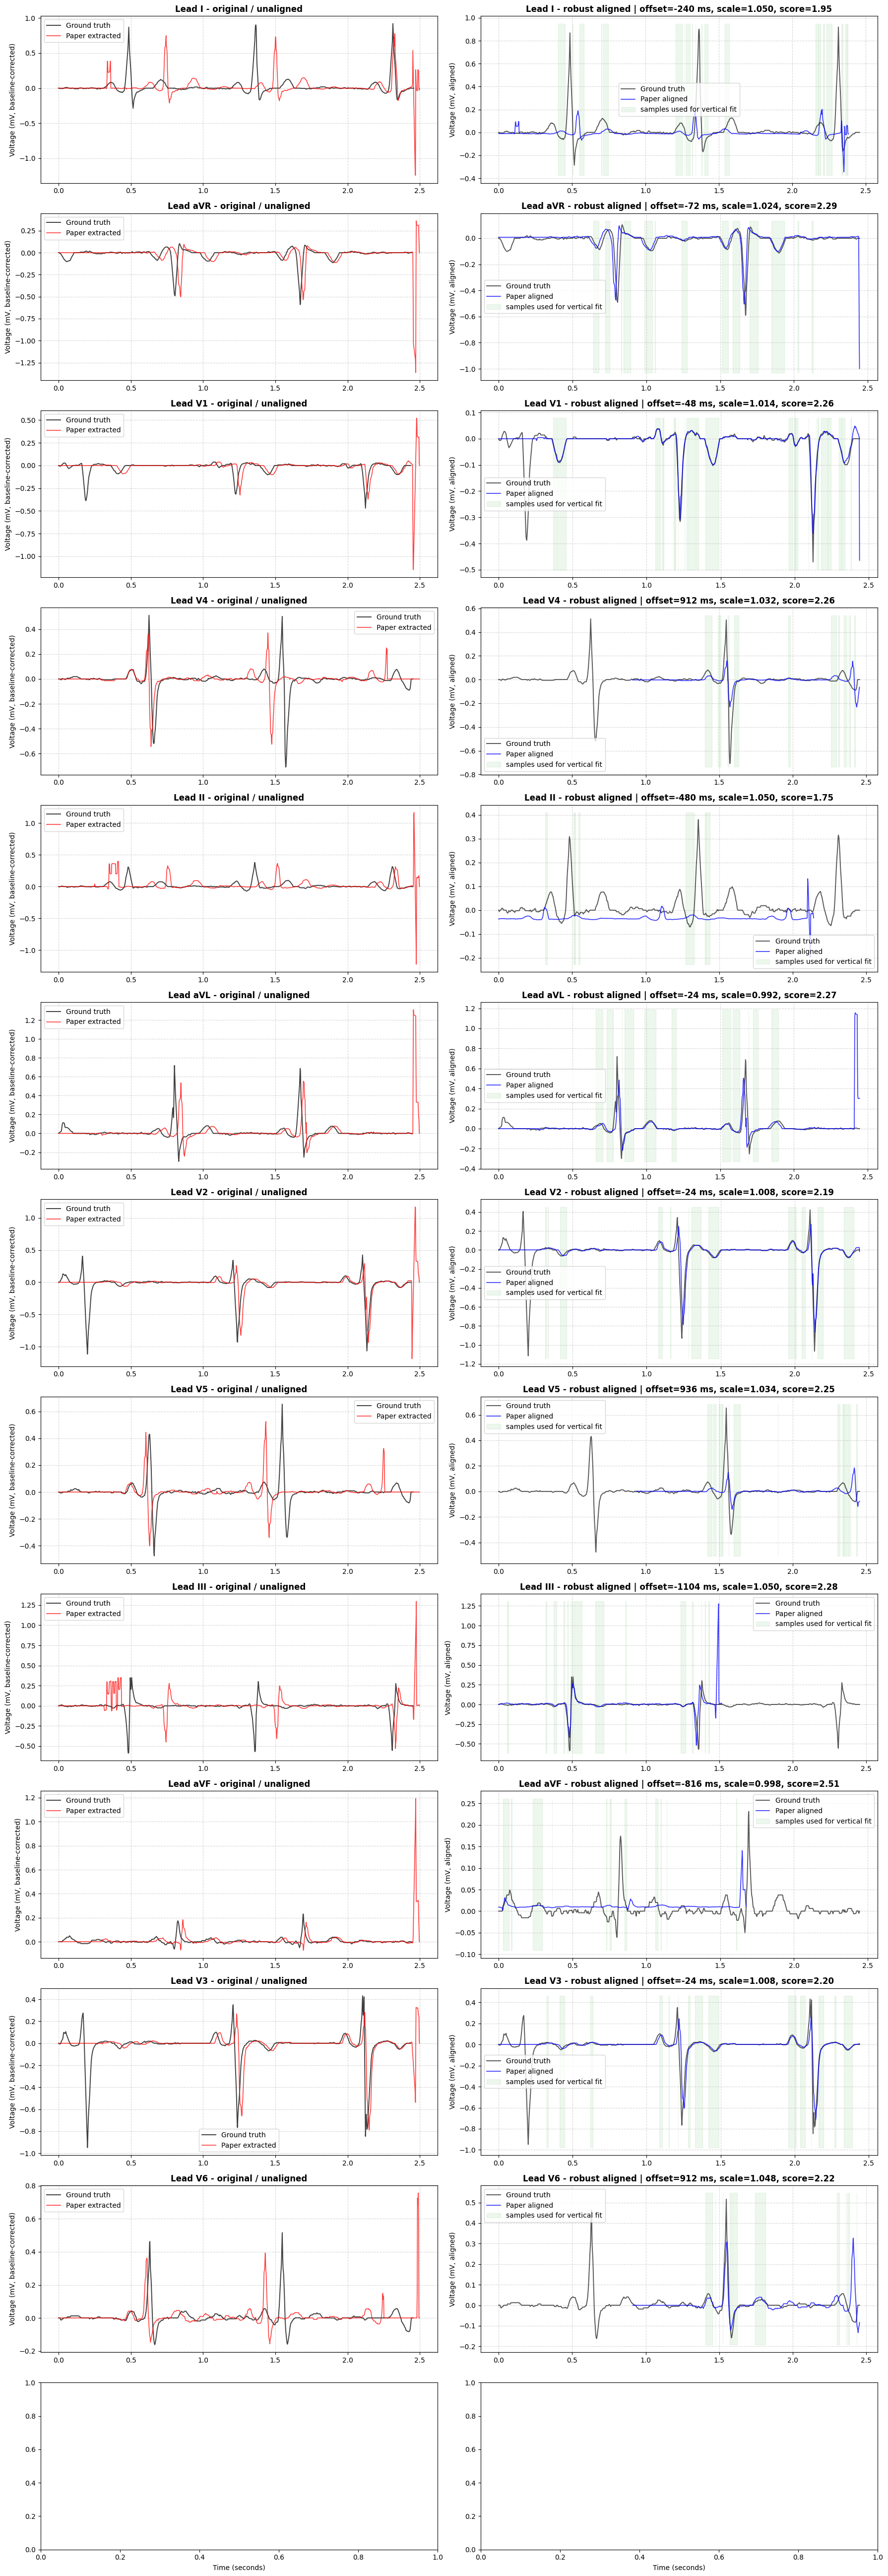

{'lead': 'I', 'offset_ms': -240.0, 'time_scale': 1.05, 'vertical_gain': 0.27799516431761256, 'vertical_offset_mv': -0.010758080168154046, 'match_score': 1.9543231983542033, 'anchor_matches': 2, 'corr_score': 0.5812871957275162, 'fit_samples': 193, 'rmse_mv': 0.05678419020218137}
{'lead': 'aVR', 'offset_ms': -72.0, 'time_scale': 1.024, 'vertical_gain': 0.9601600056236158, 'vertical_offset_mv': 0.007345477958607921, 'match_score': 2.2872939568972708, 'anchor_matches': 2, 'corr_score': 0.8386850529099066, 'fit_samples': 245, 'rmse_mv': 0.015240389744169554}
{'lead': 'V1', 'offset_ms': -48.0, 'time_scale': 1.014, 'vertical_gain': 0.9730920516711195, 'vertical_offset_mv': -0.00013756093700366032, 'match_score': 2.26466877196508, 'anchor_matches': 2, 'corr_score': 0.7600595171538942, 'fit_samples': 242, 'rmse_mv': 0.0034769534501117114}
{'lead': 'V4', 'offset_ms': 912.0, 'time_scale': 1.032, 'vertical_gain': 0.4445494081741153, 'vertical_offset_mv': -0.002849314911368974, 'match_score': 2.26

In [4]:
\
# Change this list to inspect any shared leads.
leads = ["I", "aVR", "V1", "V4", "II", "aVL", "V2", "V5", "III", "aVF", "V3", "V6", "RYTHM"]


results = {}
fig, axes = plt.subplots(len(leads), 2, figsize=(18, 4 * len(leads)), squeeze=False)

for row, lead in enumerate(leads):
    if lead not in truth_data.files or lead not in extr_data.files:
        print(f"Skipping {lead}: missing from one of the NPZ files")
        continue

    truth = truth_data[lead].astype(float)
    paper = extr_data[lead].astype(float)
    result = align_lead(truth, paper, fs_truth, fs_extr)
    results[lead] = result

    ax = axes[row, 0]
    t_truth = np.arange(len(truth)) / fs_truth
    t_paper = np.arange(len(result["paper_centered"])) / fs_truth
    ax.plot(t_truth, baseline_correct(truth, fs_truth), color="black", lw=1.4, alpha=0.75, label="Ground truth")
    ax.plot(t_paper, result["paper_centered"], color="red", lw=1.2, alpha=0.75, label="Paper extracted")
    ax.set_title(f"Lead {lead} - original / unaligned", fontweight="bold")
    ax.set_ylabel("Voltage (mV, baseline-corrected)")
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.legend(loc="best")

    ax = axes[row, 1]
    ax.plot(t_truth, result["truth_centered"], color="black", lw=1.4, alpha=0.65, label="Ground truth")
    ax.plot(t_truth, result["paper_aligned"], color="blue", lw=1.2, alpha=0.8, label="Paper aligned")

    if result["fit_mask"].any():
        ax.fill_between(
            t_truth,
            np.nanmin([result["truth_centered"], result["paper_aligned"]]) - 0.03,
            np.nanmax([result["truth_centered"], result["paper_aligned"]]) + 0.03,
            where=result["fit_mask"],
            color="tab:green",
            alpha=0.08,
            step="mid",
            label="samples used for vertical fit",
        )

    lag_ms = 1000 * result["offset_seconds"]
    ax.set_title(
        f"Lead {lead} - robust aligned | offset={lag_ms:.0f} ms, scale={result['scale']:.3f}, score={result['score']:.2f}",
        fontweight="bold",
    )
    ax.set_ylabel("Voltage (mV, aligned)")
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.legend(loc="best")

axes[-1, 0].set_xlabel("Time (seconds)")
axes[-1, 1].set_xlabel("Time (seconds)")
plt.tight_layout()
plt.show()

summary_rows = []
for lead, r in results.items():
    summary_rows.append(
        {
            "lead": lead,
            "offset_ms": 1000 * r["offset_seconds"],
            "time_scale": r["scale"],
            "vertical_gain": r["gain"],
            "vertical_offset_mv": r["vertical_offset"],
            "match_score": r["score"],
            "anchor_matches": r["anchor_matches"],
            "corr_score": r["corr_score"],
            "fit_samples": int(r["fit_mask"].sum()),
            "rmse_mv": r["rmse"],
        }
    )

try:
    import pandas as pd

    display(pd.DataFrame(summary_rows).round(4))
except Exception:
    for row in summary_rows:
        print(row)


In [20]:
\
# Optional: run the same alignment for every lead shared by both NPZ files.
all_leads = [lead for lead in truth_data.files if lead in extr_data.files and lead != "sampling_rate"]

all_results = {}
for lead in all_leads:
    all_results[lead] = align_lead(
        truth_data[lead].astype(float),
        extr_data[lead].astype(float),
        fs_truth,
        fs_extr,
    )

try:
    import pandas as pd

    display(
        pd.DataFrame(
            [
                {
                    "lead": lead,
                    "offset_ms": 1000 * r["offset_seconds"],
                    "time_scale": r["scale"],
                    "vertical_gain": r["gain"],
                    "vertical_offset_mv": r["vertical_offset"],
                    "match_score": r["score"],
                    "anchor_matches": r["anchor_matches"],
                    "corr_score": r["corr_score"],
                    "fit_samples": int(r["fit_mask"].sum()),
                    "rmse_mv": r["rmse"],
                }
                for lead, r in all_results.items()
            ]
        ).round(4)
    )
except Exception:
    for lead, r in all_results.items():
        print(
            lead,
            f"offset_ms={1000*r['offset_seconds']:.1f}",
            f"scale={r['scale']:.3f}",
            f"score={r['score']:.3f}",
            f"anchors={r['anchor_matches']}",
            f"corr={r['corr_score']:.3f}",
            f"rmse={r['rmse']:.4f}",
        )


I offset_ms=-1056.0 scale=1.046 score=2.241 anchors=2 corr=0.773 rmse=0.0399
II offset_ms=96.0 scale=0.950 score=2.042 anchors=2 corr=0.145 rmse=0.0339
III offset_ms=-1104.0 scale=1.050 score=2.266 anchors=2 corr=0.806 rmse=0.0180
aVR offset_ms=-768.0 scale=0.968 score=2.686 anchors=3 corr=0.484 rmse=0.0552
aVL offset_ms=-24.0 scale=1.010 score=2.271 anchors=2 corr=0.787 rmse=0.0165
aVF offset_ms=-816.0 scale=0.994 score=2.425 anchors=3 corr=0.152 rmse=0.0136
V1 offset_ms=-48.0 scale=1.018 score=2.256 anchors=2 corr=0.742 rmse=0.0066
V2 offset_ms=48.0 scale=0.960 score=2.159 anchors=2 corr=0.459 rmse=0.0440
V3 offset_ms=-24.0 scale=1.002 score=2.198 anchors=2 corr=0.634 rmse=0.0108
V4 offset_ms=-24.0 scale=1.050 score=2.955 anchors=3 corr=0.891 rmse=0.0172
V5 offset_ms=0.0 scale=1.050 score=2.890 anchors=3 corr=0.826 rmse=0.0318
V6 offset_ms=0.0 scale=1.050 score=2.837 anchors=3 corr=0.672 rmse=0.0204
RHYTHM offset_ms=-408.0 scale=1.044 score=10.286 anchors=10 corr=0.948 rmse=0.0074


### Validation metrics

PCC, RMSE, and SNR are computed after alignment on the matched overlap samples.

In [21]:
\
# Validation metrics for the aligned signals.
# PCC is Pearson's correlation coefficient. RMSE is in mV.
# SNR is computed as 10*log10(signal_power / error_power), using ground truth as the signal.
def validation_metrics_for_result(result):
    truth = result["truth_centered"]
    paper = result["paper_aligned"]

    # Prefer the active samples used for vertical fitting. If too few are present,
    # fall back to all valid overlapping aligned samples.
    mask = result["fit_mask"].copy()
    if mask.sum() < 10:
        mask = result["valid"] & np.isfinite(truth) & np.isfinite(paper)

    y_true = truth[mask]
    y_pred = paper[mask]

    if len(y_true) < 2:
        return {
            "samples": int(len(y_true)),
            "pcc": np.nan,
            "rmse_mv": np.nan,
            "snr_db": np.nan,
        }

    error = y_true - y_pred
    rmse = float(np.sqrt(np.mean(error**2)))

    true_std = np.std(y_true)
    pred_std = np.std(y_pred)
    if true_std < 1e-12 or pred_std < 1e-12:
        pcc = np.nan
    else:
        pcc = float(np.corrcoef(y_true, y_pred)[0, 1])

    signal_power = float(np.mean(y_true**2))
    noise_power = float(np.mean(error**2))
    snr_db = np.inf if noise_power < 1e-12 else float(10 * np.log10(signal_power / noise_power))

    return {
        "samples": int(len(y_true)),
        "pcc": pcc,
        "rmse_mv": rmse,
        "snr_db": snr_db,
    }


metric_source = all_results if "all_results" in globals() and len(all_results) else results
validation_rows = []

for lead, result in metric_source.items():
    row = {
        "lead": lead,
        "offset_ms": 1000 * result["offset_seconds"],
        "time_scale": result["scale"],
    }
    row.update(validation_metrics_for_result(result))
    validation_rows.append(row)

try:
    import pandas as pd

    validation_df = pd.DataFrame(validation_rows)
    display(validation_df.round({"offset_ms": 1, "time_scale": 4, "pcc": 4, "rmse_mv": 5, "snr_db": 2}))
except Exception:
    for row in validation_rows:
        print(row)


{'lead': 'I', 'offset_ms': -1056.0, 'time_scale': 1.046, 'samples': 159, 'pcc': 0.867278316209388, 'rmse_mv': 0.03986108905180343, 'snr_db': 6.060513649293792}
{'lead': 'II', 'offset_ms': 96.0, 'time_scale': 0.95, 'samples': 160, 'pcc': 0.40902697133089844, 'rmse_mv': 0.03387235405676826, 'snr_db': 0.9059051888534582}
{'lead': 'III', 'offset_ms': -1104.0, 'time_scale': 1.05, 'samples': 127, 'pcc': 0.9300562318210441, 'rmse_mv': 0.017986114665750595, 'snr_db': 8.698787216839678}
{'lead': 'aVR', 'offset_ms': -768.0, 'time_scale': 0.968, 'samples': 105, 'pcc': 0.16928470972640167, 'rmse_mv': 0.05522678791441585, 'snr_db': 0.12151858090462804}
{'lead': 'aVL', 'offset_ms': -24.0, 'time_scale': 1.01, 'samples': 235, 'pcc': 0.9390841206822748, 'rmse_mv': 0.016466164551098242, 'snr_db': 9.32730620601242}
{'lead': 'aVF', 'offset_ms': -816.0, 'time_scale': 0.994, 'samples': 77, 'pcc': 0.4544481533954974, 'rmse_mv': 0.013612363749699178, 'snr_db': 2.9060824161521155}
{'lead': 'V1', 'offset_ms': -